# 01 - EDA y calidad de datos

TFM Margin Analytics.

Este notebook revisa la base local `TFM_MarginAnalytics` desde SQL Server LocalDB y deja preparada la parte de analisis exploratorio antes de pasar a estadistica, machine learning y dashboard.

Objetivos:

- Comprobar que las tablas y vistas existen.
- Revisar volumen, nulos, duplicados y reglas basicas de negocio.
- Explorar ventas, margen, canales, productos e inventario.
- Guardar salidas utiles para documentacion posterior.

Capa usada: arquitectura medallion SQL. Este notebook lee principalmente de `gold` para reporting y de `silver` cuando necesita datos preparados para modelado.


## 0. Preparacion

Ejecuta esta celda primero. Si falta alguna libreria, instala las dependencias desde la raiz del proyecto con `pip install -r requirements.txt`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

from conexion_sql import read_sql
from eda_utils import resumen_calidad, tabla_nulos, perfil_numerico, asegurar_directorio

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

OUT_DATOS = asegurar_directorio(PROJECT_ROOT / "outputs" / "datos")
OUT_GRAFICOS = asegurar_directorio(PROJECT_ROOT / "outputs" / "graficos")
OUT_CALIDAD = asegurar_directorio(PROJECT_ROOT / "outputs" / "informes_calidad")

PROJECT_ROOT

WindowsPath('G:/TFM_FINAL_VERSION_2')

## 1. Conexion con SQL Server local

La conexion por defecto apunta a:

- Servidor: `(localdb)\MSSQLLocalDB`
- Base de datos: `TFM_MarginAnalytics`

Si cambia el servidor, se puede definir la variable de entorno `TFM_SQL_SERVER`.

In [2]:
info_conexion = read_sql("""
SELECT
    @@SERVERNAME AS servidor,
    DB_NAME() AS base_datos,
    SUSER_SNAME() AS usuario,
    SYSDATETIME() AS fecha_comprobacion;
""")

display(info_conexion)

G:\TFM_FINAL_VERSION_2\src\conexion_sql.py:88: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,servidor,base_datos,usuario,fecha_comprobacion
0,Ordena-yoffre\SQL_ESTUDIO,TFM_MarginAnalytics,ORDENA-YOFFRE\yoffr,2026-06-11 07:29:47.085942


## 2. Inventario de la base de datos

Primero revisamos que el modelo esta completo: tablas, numero de filas y vistas disponibles.

In [3]:
consulta_tablas = """
SELECT
    s.name AS esquema,
    t.name AS tabla,
    SUM(p.rows) AS filas
FROM sys.tables t
INNER JOIN sys.schemas s ON t.schema_id = s.schema_id
INNER JOIN sys.partitions p ON t.object_id = p.object_id
WHERE p.index_id IN (0, 1)
GROUP BY s.name, t.name
ORDER BY s.name, t.name;
"""

tablas = read_sql(consulta_tablas)
display(tablas)

tablas.to_csv(OUT_CALIDAD / "inventario_tablas.csv", index=False)

G:\TFM_FINAL_VERSION_2\src\conexion_sql.py:88: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,esquema,tabla,filas
0,dbo,dim_almacen,2
1,dbo,dim_canal,4
2,dbo,dim_categoria,16
3,dbo,dim_cliente,3000
4,dbo,dim_envio,4
5,dbo,dim_fecha,731
6,dbo,dim_marca,20
7,dbo,dim_metodo_pago,4
8,dbo,dim_producto,500
9,dbo,dim_promocion,11


In [4]:
consulta_vistas = """
SELECT
    s.name AS esquema,
    v.name AS vista
FROM sys.views v
INNER JOIN sys.schemas s ON v.schema_id = s.schema_id
ORDER BY s.name, v.name;
"""

vistas = read_sql(consulta_vistas)
display(vistas)

vistas.to_csv(OUT_CALIDAD / "inventario_vistas.csv", index=False)

G:\TFM_FINAL_VERSION_2\src\conexion_sql.py:88: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,esquema,vista
0,bronze,dim_almacen
1,bronze,dim_canal
2,bronze,dim_categoria
3,bronze,dim_cliente
4,bronze,dim_envio
5,bronze,dim_fecha
6,bronze,dim_marca
7,bronze,dim_metodo_pago
8,bronze,dim_producto
9,bronze,dim_promocion


## 3. Carga de vistas analiticas

Para el EDA usaremos principalmente las vistas en espanol. Asi evitamos repetir joins y trabajamos con nombres de negocio.

In [5]:
ventas = read_sql("SELECT TOP 75000 * FROM gold.ventas_powerbi ORDER BY fecha, id_linea_venta")
resumen_mensual = read_sql("SELECT * FROM gold.resumen_mensual")
rentabilidad_producto = read_sql("SELECT * FROM gold.rentabilidad_producto")
margen_canal = read_sql("SELECT * FROM gold.margen_canal")
riesgo_stock = read_sql("SELECT * FROM gold.riesgo_stock")
prediccion_base = read_sql("SELECT * FROM gold.prediccion_base_ventas")

ventas["fecha"] = pd.to_datetime(ventas["fecha"])

datasets = {
    "ventas": ventas,
    "resumen_mensual": resumen_mensual,
    "rentabilidad_producto": rentabilidad_producto,
    "margen_canal": margen_canal,
    "riesgo_stock": riesgo_stock,
    "prediccion_base": prediccion_base,
}

for nombre, df in datasets.items():
    print(f"{nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

display(ventas.head())

G:\TFM_FINAL_VERSION_2\src\conexion_sql.py:88: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


ventas: 75,000 filas x 67 columnas
resumen_mensual: 960 filas x 14 columnas
rentabilidad_producto: 500 filas x 16 columnas
margen_canal: 4 filas x 12 columnas
riesgo_stock: 1,000 filas x 20 columnas
prediccion_base: 26,469 filas x 14 columnas


,id_linea_venta,id_pedido,fecha,anio,mes_numero,mes_nombre,trimestre,semana_anio,dia_semana,dia_nombre,es_fin_de_semana,id_producto,codigo_producto,sku,producto,categoria,subcategoria,unidad_negocio,marca,segmento_marca,proveedor,pais_proveedor,id_cliente,codigo_cliente,segmento_cliente,pais_cliente,region_cliente,ciudad_cliente,canal_adquisicion,nivel_fidelidad,id_canal,canal,tipo_canal,comision_pct_defecto,tipo_fulfillment,ambito_pais,id_promocion,promocion,tipo_promocion,descuento_pct_promocion,id_metodo_pago,metodo_pago,fee_pago_pct,fee_pago_fijo,id_envio,tipo_envio,transportista,zona_envio,coste_envio_estimado,unidades_vendidas,precio_unitario_bruto,importe_descuento,ventas_netas,coste_producto,comision,coste_pago,coste_envio_asignado,costes_totales,margen,margen_pct,estado_margen,importe_bruto,descuento_pct_real,flag_margen_negativo,flag_margen_bajo,flag_descuento_superior_bruto,flag_registro_valido
0,2740,ORD00066521,2024-01-01,2024,1,Enero,1,1,1,Lunes,False,358,PROD000358,SKU-000358,Deporte Fitness 0358,Deporte,Fitness,Sports,Opal Charm,Value,Lisbon Kids Factory,PT,110,CUST000110,Nuevo,ES,Madrid,Madrid,Organic,Bronze,2,Amazon,Marketplace,0.15,Marketplace,ES,NaN,Sin promocion,Sin promocion,NaN,4,Contra reembolso,0.01,1.50,4,International,DHL,UE,8.90,1,16.39,0.00,16.39,11.04,2.46,1.75,5.34,20.59,-4.20,-0.26,Margen negativo,16.39,0.00,1,1,0,1
1,3113,ORD00055556,2024-01-01,2024,1,Enero,1,1,1,Lunes,False,453,PROD000453,SKU-000453,Hogar Textil hogar 0453,Hogar,Textil hogar,Home,MiniRoots,Value,Iberia Textile Group,ES,125,CUST000125,Nuevo,ES,Andalucia,Sevilla,Organic,Silver,1,Web Propia,Direct,0.00,Own,ES,NaN,Sin promocion,Sin promocion,NaN,1,Tarjeta,0.01,0.30,1,Standard,Correos,Nacional,3.50,1,77.54,0.00,77.54,49.53,0.00,1.27,3.50,54.30,23.24,0.30,Margen alto,77.54,0.00,0,0,0,1
2,3496,ORD00044591,2024-01-01,2024,1,Enero,1,1,1,Lunes,False,48,PROD000048,SKU-000048,Accesorios Bolsos 0048,Accesorios,Bolsos,Fashion,Daily Motion,Value,Porto Home Supplies,PT,140,CUST000140,Recurrente,ES,Aragon,Zaragoza,Organic,Gold,4,Shein,Marketplace,0.18,Marketplace,ES,NaN,Sin promocion,Sin promocion,NaN,2,PayPal,0.03,0.35,2,Express,SEUR,Nacional,5.95,3,93.97,0.00,281.91,160.41,50.74,8.53,3.57,223.25,58.66,0.21,Margen medio,281.91,0.00,0,0,0,1
3,3860,ORD00033626,2024-01-01,2024,1,Enero,1,1,1,Lunes,False,143,PROD000143,SKU-000143,Calzado Sandalias 0143,Calzado,Sandalias,Fashion,Siena Goods,Premium,Iberia Textile Group,ES,155,CUST000155,Premium,ES,Aragon,Zaragoza,Paid Social,Silver,3,Miravia,Marketplace,0.12,Marketplace,ES,NaN,Sin promocion,Sin promocion,NaN,3,Transferencia,0.00,0.00,3,Pickup,Punto de recogida,Nacional,1.50,1,37.47,0.00,37.47,15.12,4.50,0.00,0.90,20.52,16.95,0.45,Margen alto,37.47,0.00,0,0,0,1
4,4230,ORD00022661,2024-01-01,2024,1,Enero,1,1,1,Lunes,False,238,PROD000238,SKU-000238,Outlet Liquidacion 0238,Outlet,Liquidacion,Clearance,Marea Studio,Mid,Nice Premium Goods,FR,170,CUST000170,Recurrente,ES,Galicia,A Coruna,Organic,Gold,2,Amazon,Marketplace,0.15,Marketplace,ES,NaN,Sin promocion,Sin promocion,NaN,4,Contra reembolso,0.01,1.50,4,International,DHL,UE,8.90,1,38.19,0.00,38.19,18.59,5.73,2.07,5.34,31.73,6.46,0.17,Margen medio,38.19,0.00,0,0,0,1


## 4. Calidad de datos

Esta parte responde a una pregunta sencilla: los datos simulados son coherentes para analizarlos? No buscamos limpiar todavia, sino documentar calidad.

In [6]:
resumenes = pd.concat(
    [resumen_calidad(df, nombre) for nombre, df in datasets.items()],
    ignore_index=True,
)

display(resumenes)
resumenes.to_csv(OUT_CALIDAD / "resumen_calidad_datasets.csv", index=False)

,dataset,filas,columnas,duplicados,nulos_totales,columnas_con_nulos
0,ventas,75000,67,0,120000,2
1,resumen_mensual,960,14,0,0,0
2,rentabilidad_producto,500,16,0,0,0
3,margen_canal,4,12,0,0,0
4,riesgo_stock,1000,20,0,278,1
5,prediccion_base,26469,14,0,120,3


In [7]:
nulos_ventas = tabla_nulos(ventas)

display(nulos_ventas)
nulos_ventas.to_csv(OUT_CALIDAD / "nulos_vw_ventas_enriquecidas.csv", index=False)

,columna,nulos,porcentaje_nulos
0,id_promocion,60000,80.00
1,descuento_pct_promocion,60000,80.00


In [8]:
perfil_ventas = perfil_numerico(ventas)

display(perfil_ventas.head(30))
perfil_ventas.to_csv(OUT_CALIDAD / "perfil_numerico_ventas.csv", index=False)

,columna,count,mean,std,min,25%,50%,75%,max,nulos,ceros,negativos
0,id_linea_venta,"75,000.00","37,500.50","21,650.78",1.00,"18,750.75","37,500.50","56,250.25","75,000.00",0,0,0
1,anio,"75,000.00","2,024.50",0.50,"2,024.00","2,024.00","2,024.00","2,025.00","2,025.00",0,0,0
2,mes_numero,"75,000.00",6.52,3.45,1.00,4.00,7.00,10.00,12.00,0,0,0
3,trimestre,"75,000.00",2.51,1.12,1.00,2.00,3.00,4.00,4.00,0,0,0
4,semana_anio,"75,000.00",26.39,15.07,1.00,13.00,26.00,39.00,52.00,0,0,0
5,dia_semana,"75,000.00",3.99,2.00,1.00,2.00,4.00,6.00,7.00,0,0,0
6,id_producto,"75,000.00",250.50,144.34,1.00,125.75,250.50,375.25,500.00,0,0,0
7,id_cliente,"75,000.00","1,500.50",866.03,1.00,750.75,"1,500.50","2,250.25","3,000.00",0,0,0
8,id_canal,"75,000.00",2.50,1.12,1.00,1.75,2.50,3.25,4.00,0,0,0
9,comision_pct_defecto,"75,000.00",0.11,0.07,0.00,0.09,0.14,0.16,0.18,0,18750,0


## 5. Reglas basicas de negocio

Validamos reglas que deben cumplirse para que el analisis de margen sea creible.

In [9]:
controles = {
    "ventas_netas_negativas": int((ventas["ventas_netas"] < 0).sum()),
    "costes_totales_negativos": int((ventas["costes_totales"] < 0).sum()),
    "unidades_no_positivas": int((ventas["unidades_vendidas"] <= 0).sum()),
    "margen_pct_menor_que_menos_100": int((ventas["margen_pct"] < -1).sum()),
    "descuento_negativo": int((ventas["importe_descuento"] < 0).sum()),
    "descuento_superior_a_bruto": int((ventas["importe_descuento"] > ventas["unidades_vendidas"] * ventas["precio_unitario_bruto"]).sum()),
    "lineas_margen_negativo": int((ventas["margen"] < 0).sum()),
}

controles_df = pd.DataFrame(controles.items(), columns=["control", "resultado"])
display(controles_df)
controles_df.to_csv(OUT_CALIDAD / "controles_negocio.csv", index=False)

,control,resultado
0,ventas_netas_negativas,0
1,costes_totales_negativos,0
2,unidades_no_positivas,0
3,margen_pct_menor_que_menos_100,11
4,descuento_negativo,0
5,descuento_superior_a_bruto,0
6,lineas_margen_negativo,5808


## 6. KPIs generales

Primera vision ejecutiva de ventas, costes y margen.

In [10]:
kpis_generales = pd.DataFrame(
    {
        "metrica": [
            "pedidos",
            "lineas_venta",
            "unidades_vendidas",
            "ventas_netas",
            "costes_totales",
            "margen",
            "margen_pct",
            "ticket_medio_pedido",
        ],
        "valor": [
            ventas["id_pedido"].nunique(),
            len(ventas),
            ventas["unidades_vendidas"].sum(),
            ventas["ventas_netas"].sum(),
            ventas["costes_totales"].sum(),
            ventas["margen"].sum(),
            ventas["margen"].sum() / ventas["ventas_netas"].sum(),
            ventas.groupby("id_pedido")["ventas_netas"].sum().mean(),
        ],
    }
)

display(kpis_generales)
kpis_generales.to_csv(OUT_DATOS / "kpis_generales.csv", index=False)

,metrica,valor
0,pedidos,"75,000.00"
1,lineas_venta,"75,000.00"
2,unidades_vendidas,"110,250.00"
3,ventas_netas,"6,060,400.87"
4,costes_totales,"3,948,373.08"
5,margen,"2,112,027.79"
6,margen_pct,0.35
7,ticket_medio_pedido,80.81


## 7. Analisis por canal

Comparamos web propia y marketplaces. Este bloque es clave para el TFM porque el producto se centra en rentabilidad real, no solo en ventas.

In [11]:
eda_canal = (
    ventas.groupby(["canal", "tipo_canal"], as_index=False)
    .agg(
        pedidos=("id_pedido", "nunique"),
        unidades=("unidades_vendidas", "sum"),
        ventas_netas=("ventas_netas", "sum"),
        costes_totales=("costes_totales", "sum"),
        margen=("margen", "sum"),
        comisiones=("comision", "sum"),
        coste_pago=("coste_pago", "sum"),
        coste_envio=("coste_envio_asignado", "sum"),
    )
)
eda_canal["margen_pct"] = eda_canal["margen"] / eda_canal["ventas_netas"]
eda_canal = eda_canal.sort_values("margen", ascending=False)

display(eda_canal)
eda_canal.to_csv(OUT_DATOS / "eda_canal.csv", index=False)

,canal,tipo_canal,pedidos,unidades,ventas_netas,costes_totales,margen,comisiones,coste_pago,coste_envio,margen_pct
3,Web Propia,Direct,18750,27000,"1,655,885.85","863,716.70","792,169.15",0.00,"26,323.70","63,667.50",0.48
1,Miravia,Marketplace,18750,27750,"1,536,462.81","951,433.24","585,029.57","184,375.24",0.00,"16,875.00",0.38
2,Shein,Marketplace,18750,27750,"1,507,196.87","1,132,239.90","374,956.97","271,296.72","50,272.68","66,937.50",0.25
0,Amazon,Marketplace,18750,27750,"1,360,855.34","1,000,983.24","359,872.10","204,132.87","48,537.87","100,125.00",0.26


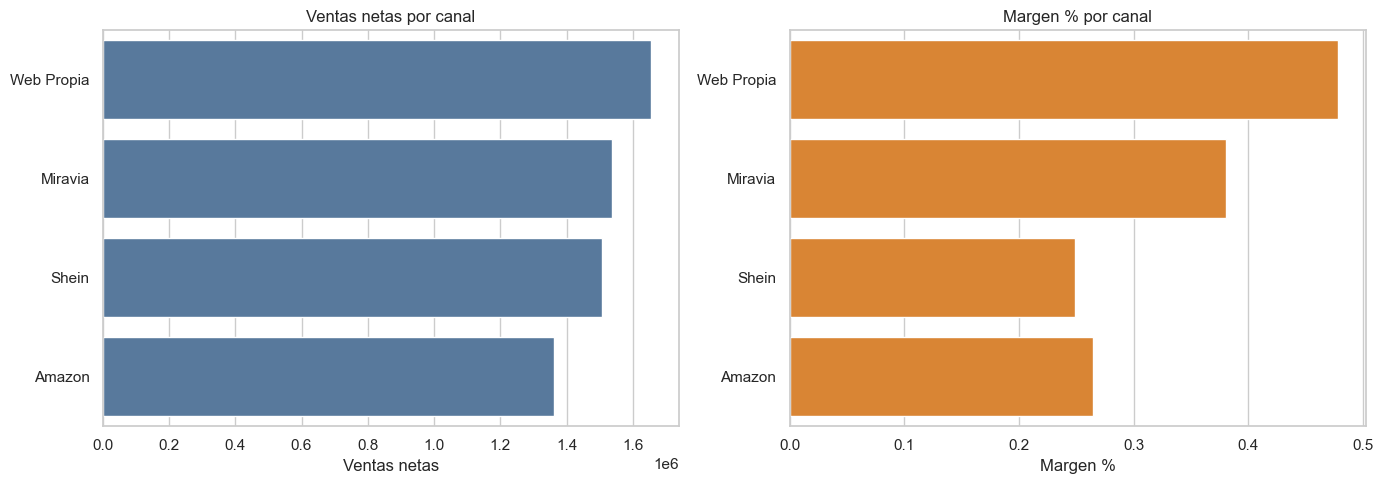

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=eda_canal, x="ventas_netas", y="canal", ax=axes[0], color="#4C78A8")
axes[0].set_title("Ventas netas por canal")
axes[0].set_xlabel("Ventas netas")
axes[0].set_ylabel("")

sns.barplot(data=eda_canal, x="margen_pct", y="canal", ax=axes[1], color="#F58518")
axes[1].set_title("Margen % por canal")
axes[1].set_xlabel("Margen %")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(OUT_GRAFICOS / "canal_ventas_margen.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Analisis por categoria y producto

Buscamos que categorias y productos aportan margen y cuales pueden estar vendiendo mucho pero dejando poco beneficio.

In [13]:
eda_categoria = (
    ventas.groupby(["categoria", "subcategoria"], as_index=False)
    .agg(
        pedidos=("id_pedido", "nunique"),
        unidades=("unidades_vendidas", "sum"),
        ventas_netas=("ventas_netas", "sum"),
        margen=("margen", "sum"),
        lineas_margen_negativo=("estado_margen", lambda s: (s == "Margen negativo").sum()),
    )
)
eda_categoria["margen_pct"] = eda_categoria["margen"] / eda_categoria["ventas_netas"]
eda_categoria = eda_categoria.sort_values("margen", ascending=False)

display(eda_categoria.head(20))
eda_categoria.to_csv(OUT_DATOS / "eda_categoria.csv", index=False)

,categoria,subcategoria,pedidos,unidades,ventas_netas,margen,lineas_margen_negativo,margen_pct
0,Accesorios,Bisuteria,4650,7500,"616,678.60","264,206.80",7,0.43
5,Calzado,Zapatillas,5700,8700,"586,887.27","236,319.89",183,0.40
7,Electronica,Accesorios movil,4500,7050,"469,437.00","158,267.00",315,0.34
12,Moda Hombre,Pantalones,5550,7950,"476,229.05","157,522.97",437,0.33
9,Hogar,Textil hogar,4650,6750,"417,918.06","152,482.36",163,0.36
11,Moda Hombre,Camisetas,5100,6450,"441,715.72","152,450.64",325,0.35
6,Deporte,Fitness,4050,6150,"452,373.65","148,450.79",367,0.33
14,Moda Mujer,Vestidos,4350,6300,"403,797.88","140,301.09",177,0.35
13,Moda Mujer,Tops,4650,6450,"382,177.08","137,278.83",370,0.36
1,Accesorios,Bolsos,4500,7350,"393,075.62","124,985.46",228,0.32


In [14]:
top_productos = (
    ventas.groupby(["codigo_producto", "producto", "categoria", "marca"], as_index=False)
    .agg(
        unidades=("unidades_vendidas", "sum"),
        ventas_netas=("ventas_netas", "sum"),
        margen=("margen", "sum"),
    )
)
top_productos["margen_pct"] = top_productos["margen"] / top_productos["ventas_netas"]

display(top_productos.sort_values("margen", ascending=False).head(15))
display(top_productos.sort_values("margen_pct", ascending=True).head(15))

top_productos.to_csv(OUT_DATOS / "eda_producto.csv", index=False)

,codigo_producto,producto,categoria,marca,unidades,ventas_netas,margen,margen_pct
164,PROD000165,Calzado Zapatillas 0165,Calzado,Velvet Point,450,"56,632.68","36,409.73",0.64
298,PROD000299,Accesorios Bisuteria 0299,Accesorios,PureSkin Lab,450,"68,130.45","36,100.29",0.53
166,PROD000167,Moda Hombre Camisetas 0167,Moda Hombre,Linen House,600,"70,544.12","30,029.73",0.43
324,PROD000325,Accesorios Bisuteria 0325,Accesorios,North Peak,300,"46,781.64","29,435.87",0.63
428,PROD000429,Calzado Zapatillas 0429,Calzado,Velvet Point,300,"40,428.24","25,420.78",0.63
128,PROD000129,Deporte Fitness 0129,Deporte,PureSkin Lab,300,"41,956.20","24,205.75",0.58
413,PROD000414,Moda Mujer Vestidos 0414,Moda Mujer,PureSkin Lab,450,"53,592.57","21,921.27",0.41
332,PROD000333,Moda Hombre Pantalones 0333,Moda Hombre,Linen House,450,"41,755.50","21,462.12",0.51
83,PROD000084,Deporte Fitness 0084,Deporte,Linen House,600,"67,503.00","20,208.93",0.30
96,PROD000097,Accesorios Bisuteria 0097,Accesorios,FitCore,450,"39,235.08","19,976.65",0.51


,codigo_producto,producto,categoria,marca,unidades,ventas_netas,margen,margen_pct
185,PROD000186,Belleza Cosmetica 0186,Belleza,NordWear,150,"1,134.25",-788.46,-0.70
285,PROD000286,Moda Mujer Tops 0286,Moda Mujer,Blue Harbor,150,"1,730.66",-728.43,-0.42
17,PROD000018,Outlet Liquidacion 0018,Outlet,Aster Beauty,150,"1,293.00",-531.36,-0.41
353,PROD000354,Accesorios Bolsos 0354,Accesorios,FitCore,150,"1,494.20",-564.07,-0.38
493,PROD000494,Outlet Liquidacion 0494,Outlet,North Peak,150,"1,351.92",-461.18,-0.34
69,PROD000070,Belleza Cuidado facial 0070,Belleza,Soft Bay,150,"1,991.69",-591.51,-0.30
320,PROD000321,Belleza Cosmetica 0321,Belleza,Urban Lane,150,877.57,-258.40,-0.29
225,PROD000226,Electronica Accesorios movil 0226,Electronica,Daily Motion,150,"2,580.25",-727.00,-0.28
355,PROD000356,Hogar Textil hogar 0356,Hogar,Luma Basics,150,"2,480.18",-558.17,-0.23
121,PROD000122,Moda Hombre Pantalones 0122,Moda Hombre,Blue Harbor,150,"2,121.29",-453.12,-0.21


## 9. Analisis temporal

Revisamos tendencia mensual de ventas y margen. Esto nos servira despues para estadistica y machine learning.

In [15]:
serie_mensual = (
    ventas.assign(periodo=ventas["fecha"].dt.to_period("M").dt.to_timestamp())
    .groupby("periodo", as_index=False)
    .agg(
        pedidos=("id_pedido", "nunique"),
        unidades=("unidades_vendidas", "sum"),
        ventas_netas=("ventas_netas", "sum"),
        margen=("margen", "sum"),
    )
)
serie_mensual["margen_pct"] = serie_mensual["margen"] / serie_mensual["ventas_netas"]

display(serie_mensual.head())
serie_mensual.to_csv(OUT_DATOS / "serie_mensual.csv", index=False)

,periodo,pedidos,unidades,ventas_netas,margen,margen_pct
0,2024-01-01,3179,4676,"255,074.65","87,821.68",0.34
1,2024-02-01,2976,4377,"241,786.53","84,495.21",0.35
2,2024-03-01,3183,4678,"257,018.59","88,779.29",0.35
3,2024-04-01,3079,4524,"250,879.61","87,922.76",0.35
4,2024-05-01,3179,4671,"256,225.07","88,988.61",0.35


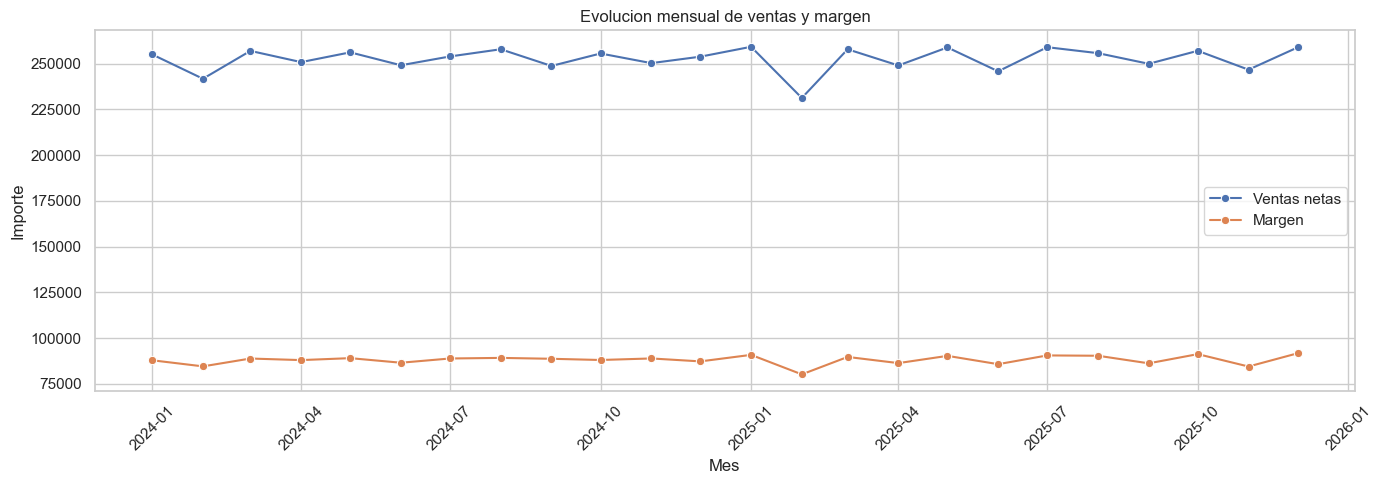

In [16]:
fig, ax1 = plt.subplots(figsize=(14, 5))

sns.lineplot(data=serie_mensual, x="periodo", y="ventas_netas", marker="o", ax=ax1, label="Ventas netas")
sns.lineplot(data=serie_mensual, x="periodo", y="margen", marker="o", ax=ax1, label="Margen")
ax1.set_title("Evolucion mensual de ventas y margen")
ax1.set_xlabel("Mes")
ax1.set_ylabel("Importe")
ax1.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(OUT_GRAFICOS / "evolucion_mensual_ventas_margen.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Distribucion de margen

Esta parte ayuda a detectar lineas con margen bajo o negativo y a justificar reglas de decision en el dashboard.

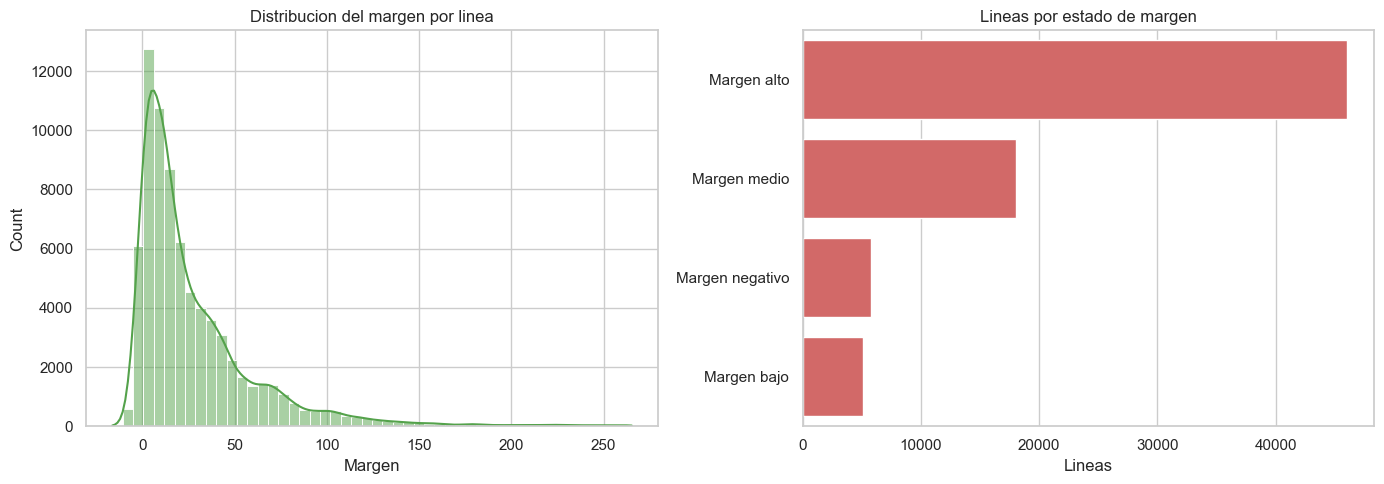

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(ventas["margen"], bins=50, kde=True, ax=axes[0], color="#54A24B")
axes[0].set_title("Distribucion del margen por linea")
axes[0].set_xlabel("Margen")

sns.countplot(data=ventas, y="estado_margen", order=ventas["estado_margen"].value_counts().index, ax=axes[1], color="#E45756")
axes[1].set_title("Lineas por estado de margen")
axes[1].set_xlabel("Lineas")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(OUT_GRAFICOS / "distribucion_margen.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Inventario y riesgo de stock

Primer analisis de stock para conectar el TFM con prediccion de demanda o riesgo de rotura en fases posteriores.

In [18]:
display(riesgo_stock.head())

if "nivel_riesgo_stock" in riesgo_stock.columns:
    resumen_stock = riesgo_stock["nivel_riesgo_stock"].value_counts().reset_index()
    resumen_stock.columns = ["nivel_riesgo_stock", "registros"]
elif "estado_stock" in riesgo_stock.columns:
    resumen_stock = riesgo_stock["estado_stock"].value_counts().reset_index()
    resumen_stock.columns = ["nivel_riesgo_stock", "registros"]
else:
    resumen_stock = riesgo_stock.head(0)

display(resumen_stock)
resumen_stock.to_csv(OUT_DATOS / "resumen_riesgo_stock.csv", index=False)

,fecha_stock,id_producto,codigo_producto,sku,producto,categoria,marca,id_almacen,almacen,region_almacen,stock_disponible,stock_reservado,unidades_entrantes,punto_reposicion,flag_riesgo_stock,unidades_dia_ultimos_30,dias_cobertura_stock,nivel_riesgo_stock,flag_riesgo_alto,estado_cobertura_stock
0,2025-12-29,1,PROD000001,SKU-000001,Moda Hombre Pantalones 0001,Moda Hombre,FitCore,1,Almacen Central,Lleida,80,2,38,30,False,0.00,NaN,Sin riesgo,0,Sin ventas recientes
1,2025-12-29,1,PROD000001,SKU-000001,Moda Hombre Pantalones 0001,Moda Hombre,FitCore,2,Almacen Secundario,Barcelona,41,4,11,5,False,0.00,NaN,Sin riesgo,0,Sin ventas recientes
2,2025-12-29,2,PROD000002,SKU-000002,Moda Hombre Pantalones 0002,Moda Hombre,MiniRoots,2,Almacen Secundario,Barcelona,76,8,14,19,False,0.03,"2,280.00",Sin riesgo,0,Cobertura suficiente
3,2025-12-29,2,PROD000002,SKU-000002,Moda Hombre Pantalones 0002,Moda Hombre,MiniRoots,1,Almacen Central,Lleida,102,5,38,21,False,0.03,"3,060.00",Sin riesgo,0,Cobertura suficiente
4,2025-12-29,3,PROD000003,SKU-000003,Belleza Cosmetica 0003,Belleza,Opal Charm,1,Almacen Central,Lleida,135,8,21,23,False,0.40,337.50,Sin riesgo,0,Cobertura suficiente


,nivel_riesgo_stock,registros
0,Sin riesgo,944
1,Riesgo alto,56


## 12. Base para prediccion futura

Esta vista no es todavia el machine learning final. Solo deja preparado el dataset agregado que podremos usar despues.

In [19]:
display(prediccion_base.head())
print(prediccion_base.shape)
prediccion_base.to_csv(OUT_DATOS / "dataset_base_prediccion.csv", index=False)

,fecha,anio,mes_numero,dia_semana,es_fin_de_semana,canal,categoria,unidades_vendidas,ventas_netas,margen_total,media_movil_7d_unidades,media_movil_30d_unidades,prediccion_naive_proximo_dia,tendencia_ventas
0,2024-01-01,2024,1,1,False,Amazon,Accesorios,4,106.32,14.01,NaN,NaN,NaN,Sin historico
1,2024-01-02,2024,1,2,False,Amazon,Accesorios,6,297.18,65.70,4.00,4.00,4.00,Tendencia estable
2,2024-01-03,2024,1,3,False,Amazon,Accesorios,6,297.18,65.70,5.00,5.00,5.00,Tendencia estable
3,2024-01-04,2024,1,4,False,Amazon,Accesorios,7,360.38,79.83,5.33,5.33,5.33,Tendencia estable
4,2024-01-05,2024,1,5,False,Amazon,Accesorios,7,360.38,79.83,5.75,5.75,5.75,Tendencia estable


(26469, 14)


## 13. Conclusiones iniciales del EDA

Completar despues de ejecutar el notebook con resultados concretos. Puntos que deberian quedar explicados en la memoria:

- Si el volumen de datos es suficiente para simular una empresa ecommerce realista.
- Si las reglas de margen se cumplen y no hay incoherencias graves.
- Que canales venden mas y cuales dejan mas margen.
- Que categorias/productos aportan mas rentabilidad.
- Si existen lineas con margen bajo o negativo que justifiquen acciones de negocio.
- Que variables temporales y de stock pueden alimentar el notebook de estadistica y ML.